<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/Ridge_Regression_key_study_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = load_diabetes()

In [5]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["TARGET"] = data.target

In [6]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [7]:
df.shape

(442, 11)

In [8]:
from  sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(df.drop(columns=["TARGET"]), df["TARGET"], test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [10]:
from sklearn.metrics import r2_score

coefs = []
r2_scores = []

for i in [0, 10, 100, 1000]:
  reg = Ridge(alpha=i)
  reg.fit(X_train, y_train)
  y_pred = reg.predict(X_test)
  r2_scores.append(r2_score(y_test, y_pred))
  coefs.append(reg.coef_.tolist())

In [11]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs=[]

for i in alphas:
  reg = Ridge(alpha=i)
  reg.fit(X_train,y_train)

  coefs.append(reg.coef_.tolist())

In [12]:
input_array = np.array(coefs)

In [14]:
coef_df = pd.DataFrame(input_array, columns=data.feature_names, index=alphas)
coef_df['alphas'] = alphas
coef_df.set_index('alphas')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alphas,,,,,,,,,,
0.0000,37.904021,-241.964362,542.428759,347.703844,-931.488846,518.062277,163.419983,275.317902,736.198859,48.670657
0.0001,37.968967,-241.900460,542.593504,347.604088,-919.863924,508.995920,158.213776,273.689919,731.714305,48.786920
0.0010,38.483505,-241.351795,543.835179,346.782831,-827.701995,437.173749,116.949753,260.759264,696.129223,49.743447
0.0100,40.693422,-237.008020,546.161792,341.809317,-430.146300,129.902301,-60.460817,203.990842,541.098025,55.482553
0.1000,42.855670,-205.494319,505.089033,317.093205,-108.500262,-86.236733,-190.363180,151.707086,392.289319,79.908177
1.0000,45.367377,-76.666086,291.338832,198.995817,-0.530310,-28.577050,-144.511905,119.260066,230.221608,112.149830
10.0000,18.229623,-3.277536,65.128417,48.219668,16.238315,10.861055,-39.208913,41.438568,57.950124,39.359401
100.0000,2.414573,0.036315,7.689592,5.786517,2.488549,1.902019,-4.832511,5.397252,7.072654,5.030673
1000.0000,0.249289,0.008728,0.783880,0.590946,0.260657,0.201464,-0.495031,0.556314,0.723795,0.517311


In [15]:
alphas = [0,0.0001,0.0005,0.001,.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
  reg = Ridge(alpha=i)
  reg.fit(X_train,y_train)

  coefs.append(reg.coef_.tolist())

In [17]:
input_array = np.array(coefs)

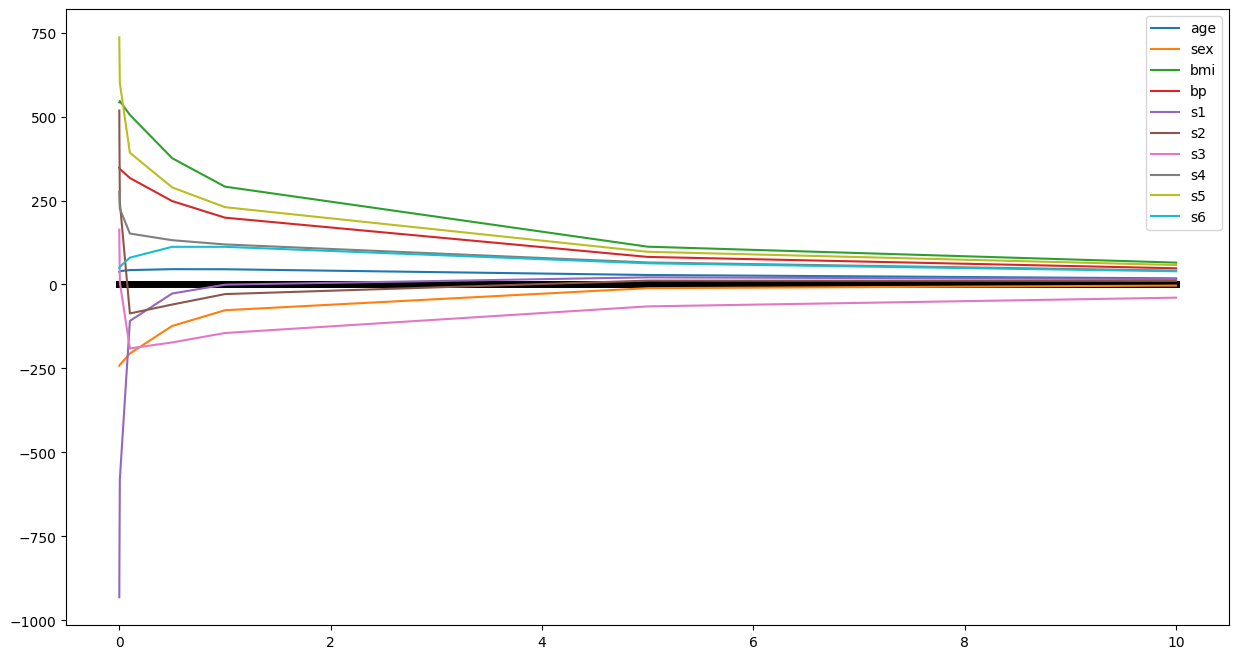

In [19]:
plt.figure(figsize=(15,8))
plt.plot(alphas, np.zeros(len(alphas)), color='black', linewidth=5)
for i in range(input_array.shape[1]):
  plt.plot(alphas, input_array[:, i], label=data.feature_names[i])

plt.legend()

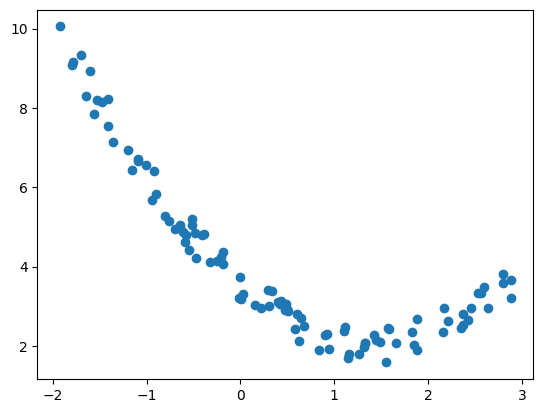

In [22]:
# Imapact on bias and variance :-
m = 100
x = 5 * np.random.rand(m,1) - 2
y = 0.7 * x ** 2 - 2 * x + 3 + np.random.rand(m,1)

plt.scatter(x, y)
plt.show()

In [24]:
X_train , X_test , y_train , y_test = train_test_split(X.reshape(100,1),y.reshape(100), test_size=0.2 , random_state=2)

In [26]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

In [27]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0, 30, 100)

loss = []
bias = []
variance = []

for i in alphas:
  reg = Ridge(alpha=i)
  avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(reg, X_train_poly, y_train, X_test_poly, y_test, loss='mse', num_rounds=100, random_seed=123)
  loss.append(avg_expected_loss)
  bias.append(avg_bias)
  variance.append(avg_var)

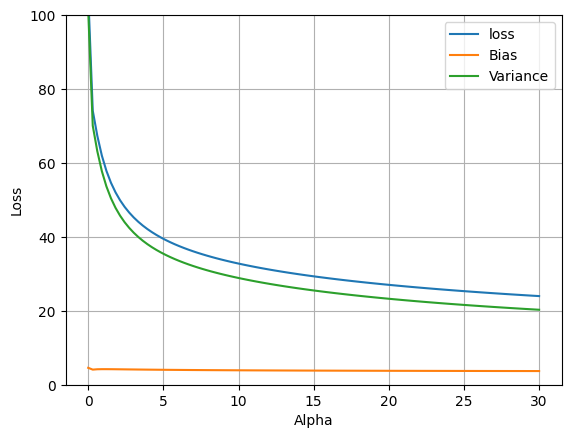

In [32]:
plt.plot(alphas , loss , label='loss')
plt.plot(alphas , bias ,label='Bias')
plt.plot(alphas , variance , label='Variance')
plt.legend()
plt.ylim(0,100)
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

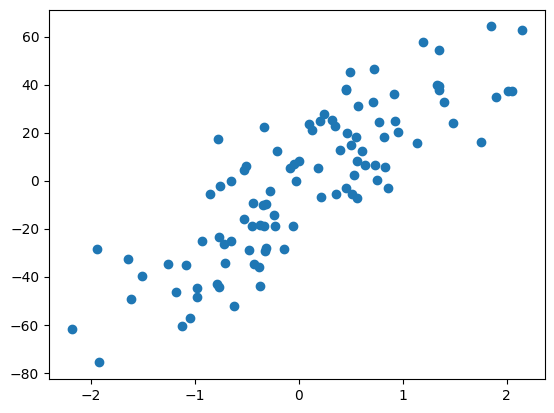

[27.82809103]
-2.29474455867698


In [33]:
 from sklearn.datasets import make_regression
 X,y = make_regression(n_samples=100, n_features=1 , n_informative=1 , n_targets=1 , noise=20 , random_state=13)
 plt.scatter(X,y)
 plt.show()

 from sklearn.linear_model import LinearRegression
 reg = LinearRegression()
 reg.fit(X,y)
 print(reg.coef_)
 print(reg.intercept_)

In [34]:
def cal_loss(m,alpha):
  return np.sum((y-m*X.ravel()+ 2.29)**2) + alpha*m*m

In [35]:
def predict(m):
  return m*X - 2.29

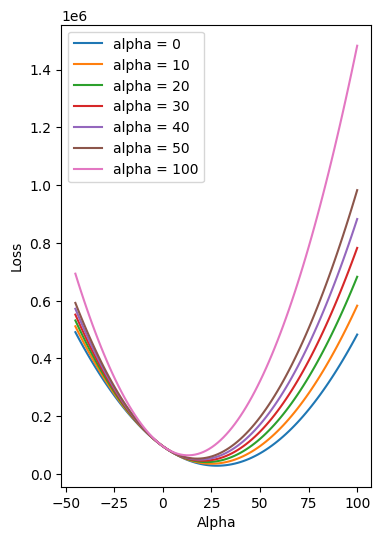

In [36]:
m = np.linspace(-45 , 100 , 100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
  loss=[]
  for i in range(m.shape[0]):
    loss_i = cal_loss(m[i],j)
    loss.append(loss_i)
  plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel("Alpha")
plt.ylabel("Loss")
plt.show()